In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/mnist-in-csv/mnist_test.csv
/kaggle/input/mnist-in-csv/mnist_train.csv
/kaggle/input/pm-107295302-at-03-19-2026-07-30-09/__script__.py
/kaggle/input/pm-107295302-at-03-19-2026-07-30-09/__results__.html
/kaggle/input/pm-107295302-at-03-19-2026-07-30-09/input_requirements.txt
/kaggle/input/pm-107295302-at-03-19-2026-07-30-09/__script__.ipynb
/kaggle/input/pm-107295302-at-03-19-2026-07-30-09/__output__.json
/kaggle/input/pm-107295302-at-03-19-2026-07-30-09/custom.css


In [2]:
import matplotlib.pyplot as plt
import time

In [3]:
data = pd.read_csv("/kaggle/input/mnist-in-csv/mnist_train.csv")
data.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
X = data.drop(columns = "label", axis = 1)
y = data.iloc[:,0]

In [5]:
X.shape

(60000, 784)

In [6]:
X.sample(3)

,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,1x10,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
44691,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
34826,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
31040,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
y.sample(3)

29860    0
3872     8
5391     9
Name: label, dtype: int64

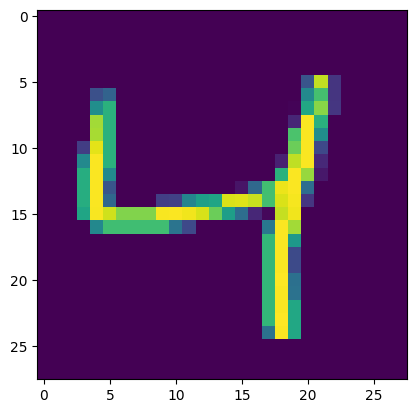

In [8]:
plt.imshow(data.iloc[2,1:].values.reshape(28,28))

In [9]:
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()

In [10]:
X_transformed = scaler.fit_transform(X)

In [11]:
# from sklearn.decomposition import PCA 
# pca = PCA()
# X_pca = pca.fit_transform(X_transformed)

In [12]:
# plt.figure(figsize = (8,5))
# plt.plot(np.cumsum(pca.explained_variance_ratio_))
# plt.xlabel("Number of Components")
# plt.ylabel("Cumulative Explained Variance")
# plt.axhline(y = 0.95, color = 'r', linestyle = '--', label = "95% variance")
# plt.axhline(y = 0.99, color = 'g', linestyle = '-.', label = "99% variance")
# plt.axhline(y = 0.98, color = 'black', linestyle = ':', label = "98% variance")
# plt.legend()
# plt.show()
##99% components are better

In [13]:
# pca = PCA(n_components=0.97)
# X_pca = pca.fit_transform(X_transformed)
# pca.n_components_

In [14]:
# X_pca

In [15]:
import tensorflow as tf
from keras import Sequential
from keras.layers import Dense, Input, Dropout, LeakyReLU, BatchNormalization
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

2026-03-19 07:39:02.431267: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773905942.611977      25 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773905942.664925      25 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773905943.146566      25 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773905943.146600      25 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773905943.146603      25 computation_placer.cc:177] computation placer alr

In [16]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [17]:
model = Sequential()

model.add(Input(shape = (784,)))
model.add(Dense(256, kernel_initializer='he_uniform', kernel_regularizer=tf.keras.regularizers.l2(5e-4) ))
model.add(LeakyReLU(negative_slope = 0.1))
model.add(BatchNormalization())
model.add(Dropout(0.1))

model.add(Dense(32, kernel_initializer='he_uniform', kernel_regularizer=tf.keras.regularizers.l2(5e-4) ))
model.add(LeakyReLU(negative_slope = 0.1))
model.add(BatchNormalization())
model.add(Dropout(0.1))

model.add(Dense(16, kernel_initializer='he_uniform', kernel_regularizer=tf.keras.regularizers.l2(5e-4) ))
model.add(LeakyReLU(negative_slope = 0.1))
model.add(BatchNormalization())

model.add(Dense(10, activation = 'softmax'))

model.summary()

I0000 00:00:1773905956.777588      25 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 211,098 (824.60 KB)

 Trainable params: 210,490 (822.23 KB)

 Non-trainable params: 608 (2.38 KB)

In [18]:
early_stop = EarlyStopping(
    monitor="val_loss",
    min_delta=0.00001,
    patience=5,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=True
)

In [19]:
lr_reducer = ReduceLROnPlateau(
    monitor='val_loss', # Watch validation loss
    factor=0.2,         # Multiply LR by 0.2 when triggered (e.g., 0.01 -> 0.002)
    patience=2,         # Wait 2 epochs with no improvement before reducing
    min_lr=1e-6,        # Don't let LR go below this value
    verbose=1           # Print a message when LR changes
)

In [20]:
model.compile(loss = 'sparse_categorical_crossentropy', optimizer  = 'Adam', metrics = ['accuracy'])
start = time.time()
history = model.fit(X_transformed,y,epochs=250,batch_size=64,validation_split=0.2,callbacks=[early_stop,lr_reducer])
print(time.time()-start)

Epoch 1/250


I0000 00:00:1773905961.284798      68 service.cc:152] XLA service 0x485737b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773905961.284835      68 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1773905961.764223      68 cuda_dnn.cc:529] Loaded cuDNN version 91002


 54/750 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4764 - loss: 1.9911

I0000 00:00:1773905964.551615      68 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8056 - loss: 0.9643 - val_accuracy: 0.9523 - val_loss: 0.3605 - learning_rate: 0.0010
Epoch 2/250
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9419 - loss: 0.3755 - val_accuracy: 0.9606 - val_loss: 0.2879 - learning_rate: 0.0010
Epoch 3/250
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9525 - loss: 0.3026 - val_accuracy: 0.9630 - val_loss: 0.2566 - learning_rate: 0.0010
Epoch 4/250
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9606 - loss: 0.2602 - val_accuracy: 0.9638 - val_loss: 0.2464 - learning_rate: 0.0010
Epoch 5/250
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9634 - loss: 0.2438 - val_accuracy: 0.9682 - val_loss: 0.2270 - learning_rate: 0.0010
Epoch 6/250
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9644 - loss: 0.2290 - val_accuracy: 0.9688 - val_loss: 0.2243 - learning_rate: 0.0010
Epoch 7/250
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9649 - loss: 0.2240 - val_a

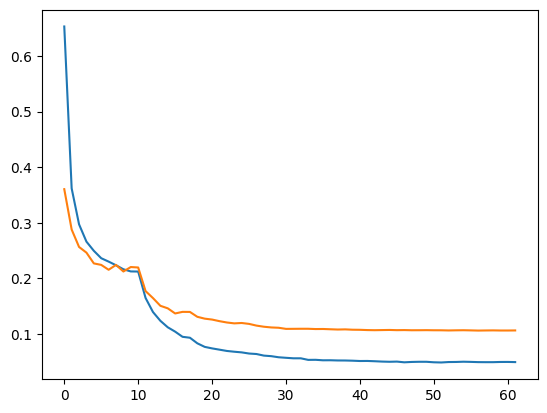

In [21]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

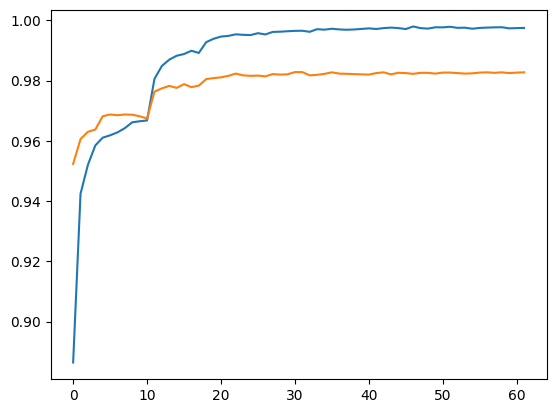

In [22]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

In [23]:
test_data = pd.read_csv("/kaggle/input/mnist-in-csv/mnist_test.csv")
X_test_data = test_data.iloc[:,1:]
y_test_data = test_data.iloc[:,0]

In [24]:
X_test_scaled = scaler.transform(X_test_data)   # NOT fit_transform
preds = model.predict(X_test_scaled)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [25]:
y_pred = np.argmax(preds, axis=1)

In [26]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test_data, y_pred)
print("Accuracy:", acc)

Accuracy: 0.9827


In [27]:
import pickle

with open("/kaggle/working/scaling.pkl", 'wb') as file:
    pickle.dump(scaler, file)

model.save('/kaggle/working/ann_model1.h5')


In [28]:
import os
from IPython.display import FileLink

os.chdir('/kaggle/working')
FileLink(r'ann_model1.h5')

/kaggle/working/ann_model1.h5

In [29]:
FileLink(r'scaling.pkl')

/kaggle/working/scaling.pkl